<a href="https://colab.research.google.com/github/Madhavi-1234/Machine-Learning-Practice/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
import seaborn as sns


In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()


In [ ]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df['target'].describe()

,target
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


In [ ]:
df.corr()['target']

,target
MedInc,0.688075
HouseAge,0.105623
AveRooms,0.151948
AveBedrms,-0.046701
Population,-0.024650
AveOccup,-0.023737
Latitude,-0.144160
Longitude,-0.045967
target,1.000000


/tmp/ipykernel_3702/3996291348.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['target'])


<Axes: xlabel='target', ylabel='Density'>

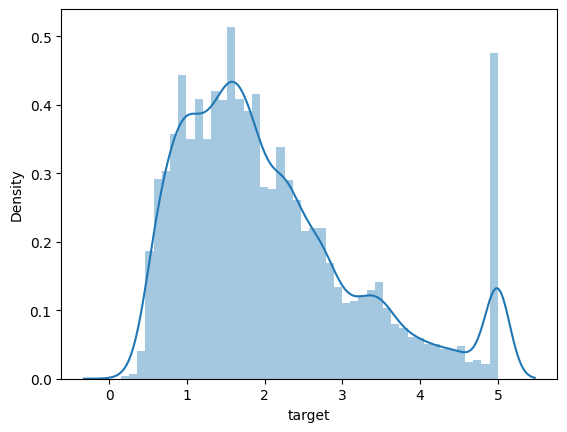

In [ ]:

# df['target'].hist()
sns.distplot(df['target'])

In [ ]:
# x and y, independant and dependant feature split
x= df.drop('target', axis= 1)
y= df['target']

In [ ]:
# train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.25, random_state= 42)

In [ ]:
#standardization

from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

In [ ]:
x_train= scaler.fit_transform(x_train)    # to inverse   #  scaler.inverse_transform()

In [ ]:
x_test= scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression()

In [ ]:
regression.fit(x_train, y_train)

LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
mse= cross_val_score(regression, x_train, y_train, scoring= 'neg_mean_squared_error', cv= 10)
mse

array([-0.52491788, -0.5652187 , -0.49800611, -0.46547425, -0.55905739,
       -0.53080338, -0.46545216, -0.55546378, -0.54287726, -0.54683194])

In [ ]:
np.mean(mse)

np.float64(-0.5254102843522996)

In [ ]:
# predict
y_pred= regression.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print( 'mse:', mean_squared_error(y_test, y_pred))
print( 'r2score:', r2_score(y_test, y_pred))
print( 'mae:' ,mean_absolute_error(y_test, y_pred))

mse: 0.5411287478470689
r2score: 0.5910509795491351
mae: 0.5296964012919462


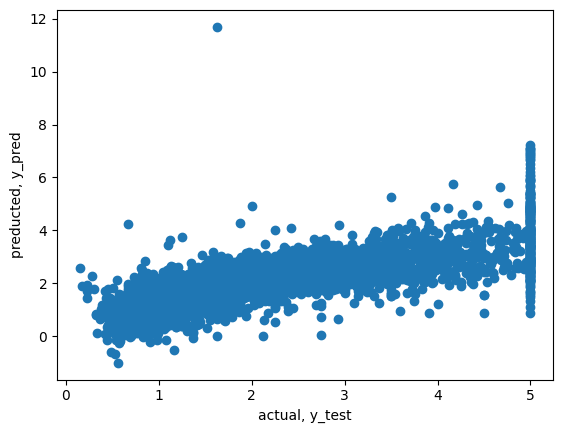

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel('actual, y_test')
plt.ylabel('preducted, y_pred')
plt.show()